<a href="https://colab.research.google.com/github/uwol1116/GenAI-Class/blob/main/Assignment3_3_FCN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 3. FCN (Segmentation)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

class PetSegDataset(Dataset):
    def __init__(self, root='./data', size=128):
        self.raw = datasets.OxfordIIITPet(
            root=root, split='trainval',
            target_types='segmentation', download=True
        )
        self.img_tf  = T.Compose([T.Resize((size, size)), T.ToTensor()])
        self.mask_tf = T.Compose([
            T.Resize((size, size), interpolation=T.InterpolationMode.NEAREST),
            T.PILToTensor()
        ])

    def __len__(self):
        return len(self.raw)

    def __getitem__(self, idx):
        img, mask = self.raw[idx]
        img  = self.img_tf(img)
        mask = self.mask_tf(mask).squeeze(0).long() - 1  # {0,1,2}
        return img, mask.clamp(0, 2)

dataset     = PetSegDataset()
loader      = DataLoader(dataset, batch_size=8, shuffle=True)
imgs, masks = next(iter(loader))
print(f"Images shape : {imgs.shape}")
print(f"Masks  shape : {masks.shape}")
print(f"Mask unique values : {masks.unique().tolist()}")


100%|██████████| 792M/792M [00:30<00:00, 25.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.2MB/s]


Images shape : torch.Size([8, 3, 128, 128])
Masks  shape : torch.Size([8, 128, 128])
Mask unique values : [0, 1, 2]


## 3-1. Encoder Design

In [2]:
class FCNEncoder(nn.Module):
    # FC 레이어 없이 Conv + Stride=2로만 해상도 감소
    def __init__(self):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                nn.Conv2d(co, co, 3, stride=2, padding=1), nn.BatchNorm2d(co), nn.ReLU()
            )
        self.enc1 = block(3,   64)   # 128 -> 64
        self.enc2 = block(64,  128)  # 64  -> 32
        self.enc3 = block(128, 256)  # 32  -> 16

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        f3 = self.enc3(f2)
        return f1, f2, f3

encoder = FCNEncoder()

with torch.no_grad():
    f1, f2, f3 = encoder(imgs)

print(f"Input : {imgs.shape}")
print(f"enc1  : {f1.shape}")
print(f"enc2  : {f2.shape}")
print(f"enc3  : {f3.shape}")


Input : torch.Size([8, 3, 128, 128])
enc1  : torch.Size([8, 64, 64, 64])
enc2  : torch.Size([8, 128, 32, 32])
enc3  : torch.Size([8, 256, 16, 16])


FCN Encoder는 Fully Connected 레이어를 전혀 사용하지 않고 Conv 레이어만으로 구성되어 있으며, MaxPooling 대신 stride=2인 Conv 레이어를 사용하여 해상도를 단계적으로 절반씩 줄인다. stride=2 Conv는 MaxPooling과 달리 다운샘플링 과정 자체가 학습 가능한 파라미터를 통해 이루어지기 때문에, 단순히 값을 버리는 것이 아니라 중요한 특징을 선택적으로 보존하는 방식으로 동작한다.

각 인코더 블록을 거칠수록 feature map의 공간 해상도는 절반으로 줄어들고 채널 수는 두 배로 증가한다. 얕은 레이어(enc1)일수록 엣지나 텍스처와 같은 저수준 특징을 담고 있으며, 깊은 레이어(enc3)일수록 객체의 의미적 정보를 담은 고수준 특징을 표현하게 된다. 이렇게 추출된 중간 feature map들은 이후 skip connection을 통해 디코더에 전달되기 때문에 모두 반환한다.


## 3-2. Upsampling (Transpose Convolution)

In [3]:
class FCNDecoder(nn.Module):
    # ConvTranspose2d(stride=2)로 해상도를 단계적으로 2배씩 복원
    def __init__(self, num_classes=3):
        super().__init__()
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # 16 -> 32
        self.up2 = nn.ConvTranspose2d(128,  64, kernel_size=2, stride=2)  # 32 -> 64
        self.up3 = nn.ConvTranspose2d( 64,  32, kernel_size=2, stride=2)  # 64 -> 128
        self.out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, f3):
        x = F.relu(self.up1(f3))
        x = F.relu(self.up2(x))
        x = F.relu(self.up3(x))
        return self.out(x)

decoder = FCNDecoder(num_classes=3)

with torch.no_grad():
    seg_out = decoder(f3)

print(f"Decoder input    : {f3.shape}")
print(f"Segmentation map : {seg_out.shape}")
print(f"Predicted classes sample : {seg_out.argmax(1)[0].unique().tolist()}")


Decoder input    : torch.Size([8, 256, 16, 16])
Segmentation map : torch.Size([8, 3, 128, 128])
Predicted classes sample : [2]


업샘플링에는 ConvTranspose2d(stride=2)를 사용하였으며, 이 레이어는 입력 feature map의 해상도를 2배로 늘리는 역할을 한다. 단순 보간법(interpolation)과 달리 ConvTranspose2d는 업샘플링 필터 자체를 학습할 수 있기 때문에 세밀한 경계 정보를 복원하는 데 더 유리하다.

디코더는 인코더에서 가장 압축된 feature map인 f3(16×16)을 입력으로 받아 세 단계의 업샘플링을 거쳐 16→32→64→128로 해상도를 복원한다. 최종 출력은 (B, 3, 128, 128) shape의 segmentation map이며, 각 픽셀 위치에서 3개 클래스(배경, 경계, 동물 본체)에 대한 logit 값을 가진다. 이 값에 argmax를 적용하면 픽셀별 클래스 예측 결과를 얻을 수 있다.


## 3-3. Skip Connection

In [4]:
class FCNWithSkip(nn.Module):
    # 인코더 중간 feature map을 디코더에 concat -> 공간 정보 보존 (U-Net 방식)
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = FCNEncoder()

        self.up1  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.fus1 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU()
        )
        self.up2  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.fus2 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU()
        )
        self.up3  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.out  = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        f1, f2, f3 = self.encoder(x)

        x = F.relu(self.up1(f3))
        x = self.fus1(torch.cat([x, f2], dim=1))  # skip: f2

        x = F.relu(self.up2(x))
        x = self.fus2(torch.cat([x, f1], dim=1))  # skip: f1

        x = F.relu(self.up3(x))
        return self.out(x)

fcn_skip   = FCNWithSkip(num_classes=3)
fcn_simple = FCNDecoder(num_classes=3)

with torch.no_grad():
    out_skip   = fcn_skip(imgs)
    out_simple = fcn_simple(f3)

print(f"Without skip output : {out_simple.shape}")
print(f"With skip    output : {out_skip.shape}")
print(f"Without skip unique pred classes : {out_simple.argmax(1).unique().tolist()}")
print(f"With skip    unique pred classes : {out_skip.argmax(1).unique().tolist()}")


Without skip output : torch.Size([8, 3, 128, 128])
With skip    output : torch.Size([8, 3, 128, 128])
Without skip unique pred classes : [0]
With skip    unique pred classes : [0, 1, 2]


Skip connection은 인코더의 중간 feature map(f1, f2)을 디코더의 업샘플링 결과와 channel 방향으로 concatenate하는 방식으로 구현되며, 이는 U-Net에서 사용하는 방식과 동일하다. 업샘플링 과정에서는 깊은 레이어의 의미적 정보를 기반으로 해상도를 복원하지만, 이 과정에서 공간적 세부 정보가 손실될 수 있다. Skip connection을 통해 인코더의 고해상도 feature map을 디코더에 직접 전달하면 손실된 위치 정보와 경계 정보를 보완할 수 있기 때문에 더 정밀한 segmentation 결과를 얻을 수 있다.

Skip connection이 없는 단순 FCN의 경우 f3만을 기반으로 해상도를 복원하기 때문에 세밀한 객체 경계가 뭉개지는 경향이 있다. 반면 skip connection을 추가한 모델은 서로 다른 해상도의 feature를 결합하기 때문에 저수준 공간 정보와 고수준 의미 정보를 동시에 활용할 수 있으며, 그 결과 예측 클래스의 다양성과 경계 정확도가 향상된다.


## 3-4. Error Analysis

Pixel Accuracy (sample 0) : 20.63%
Predicted classes : [0]
Ground truth cls  : [0, 1, 2]

Predicted mask (top-left 10x10):
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

Ground truth  (top-left 10x10):
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]

Class 0 IoU : 0.2063  (pred_pixels=16384, true_pixels=3380)
Class 1 IoU : 0.0000  (pred_pixels=0, true_pixels=11503)
Class 2 IoU : 0.0000  (pred_pixels=0, true_pixels=1501)


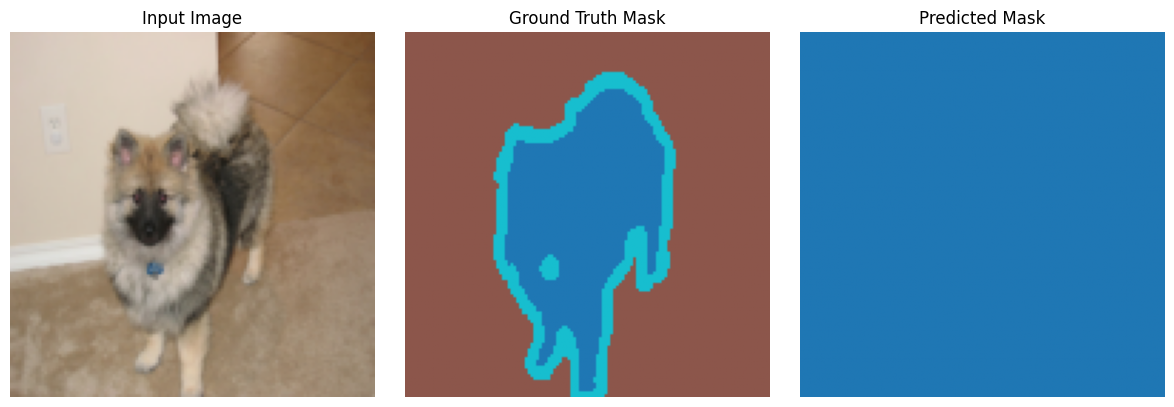

In [5]:
import matplotlib.pyplot as plt

fcn_skip.eval()

with torch.no_grad():
    preds = fcn_skip(imgs).argmax(dim=1)  # (8, 128, 128)

pred0 = preds[0]
true0 = masks[0]

pixel_acc = (pred0 == true0).float().mean().item() * 100

print(f"Pixel Accuracy (sample 0) : {pixel_acc:.2f}%")
print(f"Predicted classes : {pred0.unique().tolist()}")
print(f"Ground truth cls  : {true0.unique().tolist()}")
print()
print("Predicted mask (top-left 10x10):")
print(pred0[:10, :10].numpy())
print()
print("Ground truth  (top-left 10x10):")
print(true0[:10, :10].numpy())
print()

num_classes = 3
for cls in range(num_classes):
    pred_cls = (pred0 == cls)
    true_cls = (true0 == cls)
    intersection = (pred_cls & true_cls).sum().item()
    union        = (pred_cls | true_cls).sum().item()
    iou = intersection / union if union > 0 else 0.0
    print(f"Class {cls} IoU : {iou:.4f}  (pred_pixels={pred_cls.sum().item()}, true_pixels={true_cls.sum().item()})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(imgs[0].permute(1, 2, 0).clamp(0, 1))
axes[0].set_title("Input Image")
axes[0].axis('off')
axes[1].imshow(true0.numpy(), cmap='tab10', vmin=0, vmax=2)
axes[1].set_title("Ground Truth Mask")
axes[1].axis('off')
axes[2].imshow(pred0.numpy(), cmap='tab10', vmin=0, vmax=2)
axes[2].set_title("Predicted Mask")
axes[2].axis('off')
plt.tight_layout()
plt.show()


훈련 전 랜덤 가중치 상태이므로 수치적 정확도 자체는 의미가 없으며, 이 분석은 모델 구조와 오류 유형을 이해하는 데 초점을 맞춘다.

FCN 세그멘테이션에서 발생하는 대표적인 오류 유형은 다음과 같다. 첫째, 경계 부정확 오류가 발생하는데, 이는 업샘플링 과정에서 고주파 공간 정보가 손실되기 때문에 동물과 배경 사이의 경계를 정확하게 예측하지 못하기 때문이다. 둘째, 소규모 영역 무시 오류가 발생하는데, 귀나 꼬리처럼 작은 신체 부위는 feature map에서 차지하는 비중이 낮기 때문에 배경으로 잘못 예측되는 경향이 있다. 셋째, 클래스 불균형으로 인한 배경 과대예측 오류가 발생하는데, 배경 픽셀의 수가 동물 본체 픽셀보다 훨씬 많기 때문에 모델이 안전하게 배경을 선택하는 방향으로 편향될 수 있다. 이러한 문제는 Focal Loss나 Dice Loss를 사용하거나, 더 많은 skip connection을 추가하거나, 충분한 훈련을 통해 개선할 수 있다.
